In [1]:
print('Hello World!')

Hello World!


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge


In [10]:
df = pd.read_csv('train.csv')
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [11]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

/var/folders/k8/kc8jrng519q81_pvhp9qvnyr0000gn/T/ipykernel_1367/1919383789.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [13]:
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [14]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [ ]:
df = pd.get_dummies(df, drop_first=True)
y = df["SalePrice"]
X = df.drop(columns=["SalePrice", "Id"]) 

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_under = LinearRegression()

X_train_small = X_train.iloc[:, :2]
X_test_small = X_test.iloc[:, :2]

model_under.fit(X_train_small, y_train)

train_pred = model_under.predict(X_train_small)
test_pred = model_under.predict(X_test_small)

print("Underfit Train Error:", mean_squared_error(y_train, train_pred))
print("Underfit Test Error:", mean_squared_error(y_test, test_pred))

Underfit Train Error: 5380927099.017103
Underfit Test Error: 6484059296.122451


In [19]:

feature = X.columns[0]

X_plot = X[[feature]].values
y_plot = y.values

sorted_idx = X_plot[:, 0].argsort()
X_plot_sorted = X_plot[sorted_idx]
y_plot_sorted = y_plot[sorted_idx]

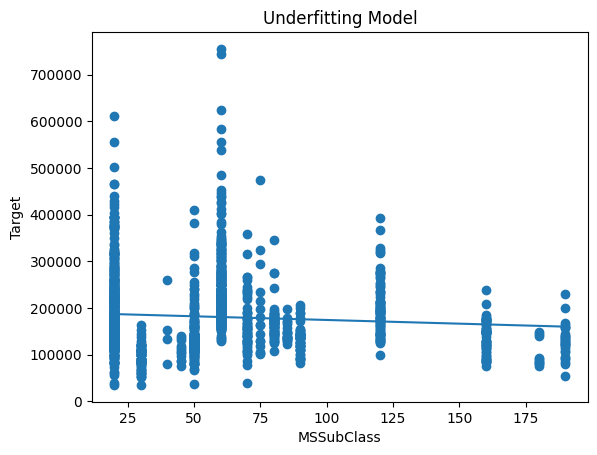

In [20]:
model_under.fit(X_plot, y)

y_pred_under = model_under.predict(X_plot_sorted)

plt.scatter(X_plot, y_plot)
plt.plot(X_plot_sorted, y_pred_under)

plt.title("Underfitting Model")
plt.xlabel(feature)
plt.ylabel("Target")
plt.show()

In [32]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

model_over = DecisionTreeRegressor(max_depth=None) 
model_over.fit(X_train, y_train)

train_pred = model_over.predict(X_train)
test_pred = model_over.predict(X_test)

print("Overfit Train Error:", mean_squared_error(y_train, train_pred))
print("Overfit Test Error:", mean_squared_error(y_test, test_pred))

Overfit Train Error: 0.0
Overfit Test Error: 2035025905.541096


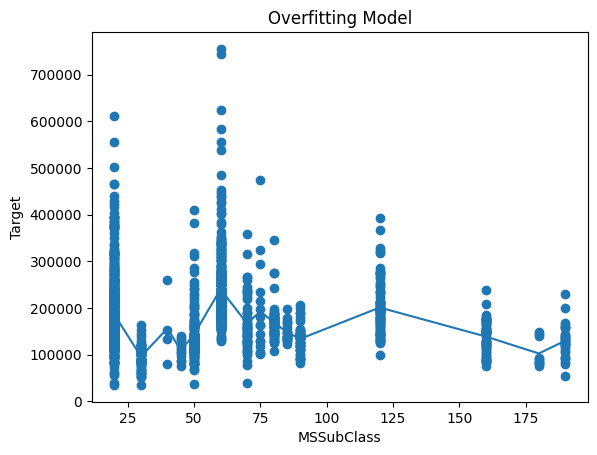

In [35]:
model_over.fit(X_plot, y)

y_pred_over = model_over.predict(X_plot_sorted)

plt.scatter(X_plot, y_plot)
plt.plot(X_plot_sorted, y_pred_over)

plt.title("Overfitting Model")
plt.xlabel(feature)
plt.ylabel("Target")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_good = DecisionTreeRegressor(max_depth=5)
model_good.fit(X_train, y_train)
train_pred = model_good.predict(X_train)
test_pred = model_good.predict(X_test)

print("Train Error:", mean_squared_error(y_train, train_pred))
print("Test Error:", mean_squared_error(y_test, test_pred))

Good Train Error: 821017524.401068
Good Test Error: 1508287192.2443194


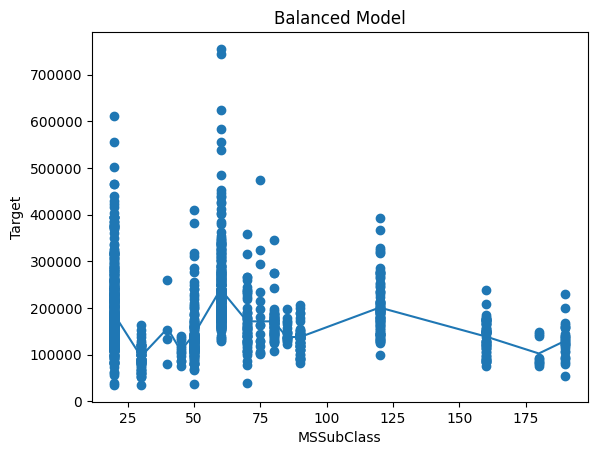

In [25]:
model_good.fit(X_plot, y)

y_pred_good = model_good.predict(X_plot_sorted)

plt.scatter(X_plot, y_plot)
plt.plot(X_plot_sorted, y_pred_good)

plt.title("Balanced Model")
plt.xlabel(feature)
plt.ylabel("Target")
plt.show()

In [44]:
from sklearn.tree import DecisionTreeRegressor

model_good = DecisionTreeRegressor(max_depth=3)
model_good.fit(X_train, y_train)
train_pred = model_good.predict(X_train)
test_pred = model_good.predict(X_test)

print("Good Train Error:", mean_squared_error(y_train, train_pred))
print("Good Test Error:", mean_squared_error(y_test, test_pred))

Good Train Error: 1596761350.9240172
Good Test Error: 1753461094.37907


In [46]:
alphas = [1, 5, 10, 20, 30, 50]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print(f"Alpha {a}")
    print("Train:", mean_squared_error(y_train, train_pred))
    print("Test :", mean_squared_error(y_test, test_pred))
    print()

Alpha 1
Train: 524907560.4606731
Test : 931275737.7984122

Alpha 5
Train: 597248937.7988029
Test : 932384206.579757

Alpha 10
Train: 636037466.231984
Test : 945666809.5328904

Alpha 20
Train: 685686000.593876
Test : 970677472.7554046

Alpha 30
Train: 721043151.0447137
Test : 991744091.9695113

Alpha 50
Train: 772203850.8178993
Test : 1025103357.78654



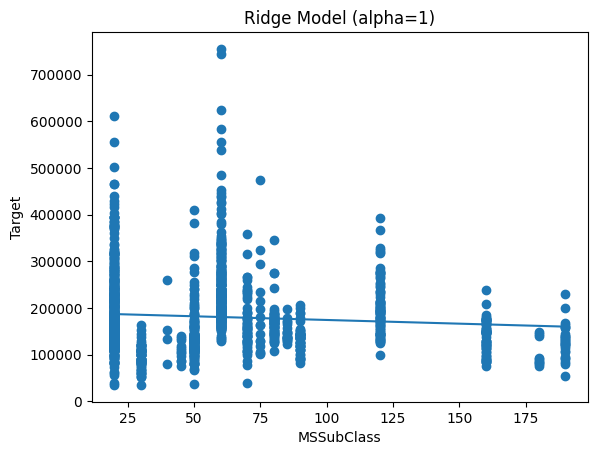

In [48]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

model_ridge = Ridge(alpha=1)
model_ridge.fit(X_plot, y_plot)

y_pred_ridge = model_ridge.predict(X_plot_sorted)

plt.scatter(X_plot, y_plot)
plt.plot(X_plot_sorted, y_pred_ridge)

plt.title("Ridge Model (alpha=1)")
plt.xlabel(feature)
plt.ylabel("Target")
plt.show()

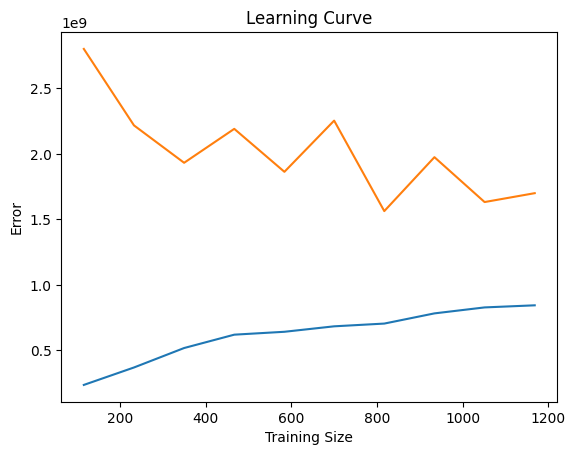

In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model_good, X, y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

plt.plot(train_sizes, train_errors)
plt.plot(train_sizes, test_errors)

plt.xlabel("Training Size")
plt.ylabel("Error")
plt.title("Learning Curve")
plt.show()

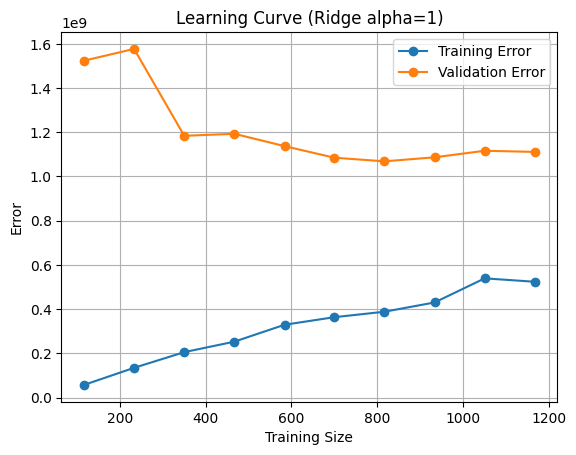

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge

model = Ridge(alpha=1)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X, y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_errors, marker='o', label="Training Error")
plt.plot(train_sizes, test_errors, marker='o', label="Validation Error")

plt.xlabel("Training Size")
plt.ylabel("Error")
plt.title("Learning Curve (Ridge alpha=1)")
plt.legend()
plt.grid()
plt.show()